# Plot autoresearch results

Edit the config values in the code cell below to switch inputs, such as `@result_small.tsv`, or to change the title.

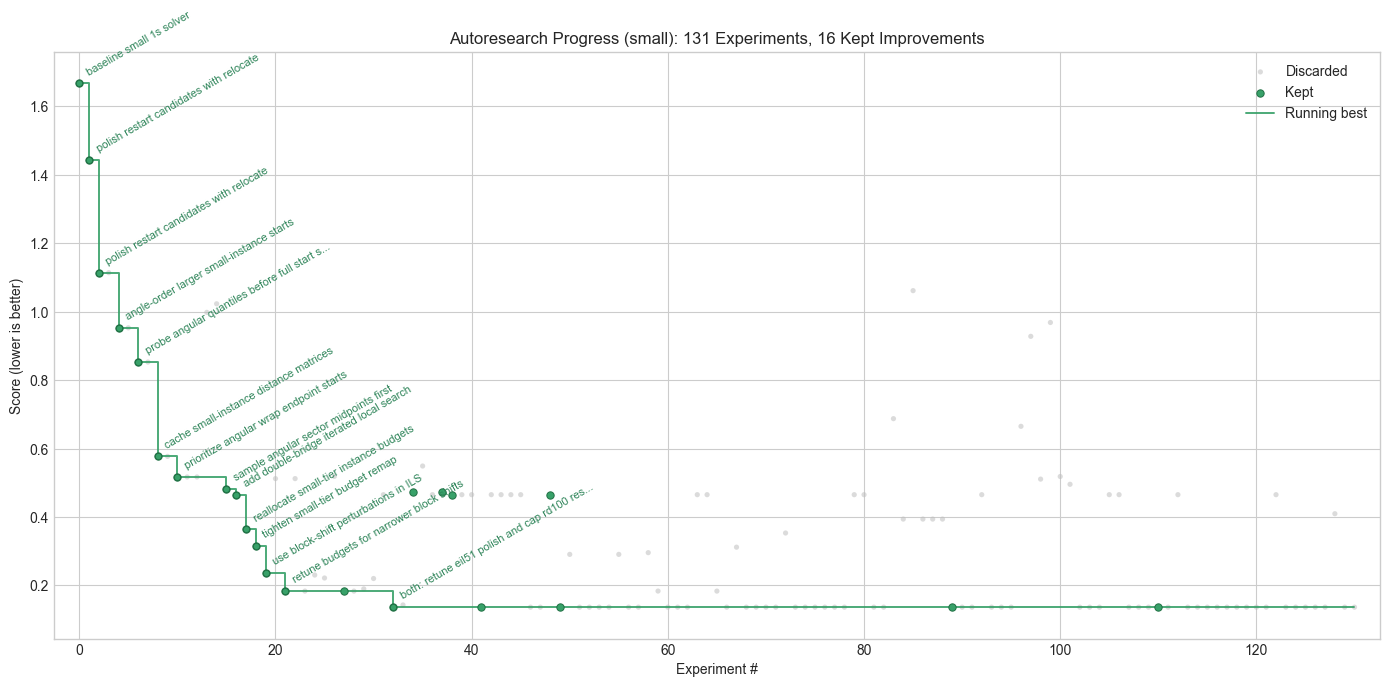

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_PATH = "results_small.tsv"  # Example: "@result_small.tsv"
BENCHMARK_SIZE = "small"  # Change to "medium" or "large" as needed
TITLE_TEMPLATE = "Autoresearch Progress ({size}): {total} Experiments, {kept} Kept Improvements"
Y_AXIS_LABEL = "Score (lower is better)"
FIGSIZE = (14, 7)
ANNOTATE_RUNNING_BEST = True


def resolve_results_path(path_like: str) -> Path:
    return Path(str(path_like).strip().lstrip("@"))


def shorten(text: str, max_chars: int = 46) -> str:
    text = str(text).strip()
    return text if len(text) <= max_chars else text[: max_chars - 3] + "..."


path = resolve_results_path(RESULTS_PATH)
df = pd.read_csv(path, sep="\t").copy()

required_columns = {"commit", "score", "runtime_s", "status", "description"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in {path}: {sorted(missing_columns)}")

df["score"] = pd.to_numeric(df["score"], errors="raise")
df["experiment"] = range(len(df))
df["is_keep"] = df["status"].eq("keep")
df["is_baseline"] = df["status"].eq("baseline")
df["is_highlight"] = df["is_keep"] | df["is_baseline"]
df["running_best"] = df["score"].cummin()

discarded = df.loc[~df["is_highlight"]]
highlighted = df.loc[df["is_highlight"]]
running_best_points = df.loc[df["running_best"].diff().fillna(-1).ne(0)].copy()

total_experiments = len(df)
kept_experiments = int(df["is_keep"].sum())
title = TITLE_TEMPLATE.format(
    size=BENCHMARK_SIZE,
    total=total_experiments,
    kept=kept_experiments,
    path=path.name,
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(
    discarded["experiment"],
    discarded["score"],
    s=14,
    color="#bfbfbf",
    alpha=0.55,
    edgecolors="none",
    label="Discarded",
)

ax.scatter(
    highlighted["experiment"],
    highlighted["score"],
    s=28,
    color="#38a169",
    edgecolors="#1f6f43",
    linewidths=0.7,
    zorder=3,
    label="Kept",
)

ax.step(
    df["experiment"],
    df["running_best"],
    where="post",
    color="#38a169",
    linewidth=1.4,
    alpha=0.9,
    label="Running best",
)

ax.scatter(
    running_best_points["experiment"],
    running_best_points["running_best"],
    s=20,
    color="#38a169",
    edgecolors="#1f6f43",
    linewidths=0.6,
    zorder=4,
)

if ANNOTATE_RUNNING_BEST:
    for row in running_best_points.itertuples(index=False):
        ax.annotate(
            shorten(row.description),
            (row.experiment, row.running_best),
            xytext=(4, 6),
            textcoords="offset points",
            rotation=30,
            fontsize=8,
            color="#2f855a",
        )

ax.set_title(title)
ax.set_xlabel("Experiment #")
ax.set_ylabel(Y_AXIS_LABEL)
ax.legend(loc="best")
ax.margins(x=0.02, y=0.06)

plt.tight_layout()
plt.show()
